# AI Vision : Classification d'images

**Objectif :** entraîner un modèle `cat/dog` dans ce notebook, sauvegarder `model/image_classifier.pkl`, puis l'utiliser avec FastAPI et Streamlit.

> Il n'y a volontairement pas de `train.py`. L'entraînement est fait dans ce `.ipynb`.

Architecture : `Dataset → Jupyter → model.pkl → FastAPI → Streamlit`.

# ÉTAPE 01 : Imports

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
print("Imports OK")

Imports OK


# ÉTAPE 02 : Chemins et paramètres

In [ ]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "model"
IMAGE_SIZE = (32,32)
print(DATA_DIR)

/Users/mac/Downloads/Data Science - Bootcamp/Deep Learning NVIDIA certified/08 Déployer un modèle d’IA avec FastAPI et Streamlit/fastapi_streamlit_image_project/data


# ÉTAPE 03 : Charger et transformer les images
Chaque image devient 3072 nombres : 32*32*3.

In [ ]:
X, y = [], []
for label in ["cat","dog"]:
    for path in sorted((DATA_DIR/label).glob("*.png")):
        image=Image.open(path).convert("RGB").resize(IMAGE_SIZE)
        array=np.asarray(image,dtype=np.float32)/255.0
        X.append(array.reshape(-1))
        y.append(label)
X=np.array(X); y=np.array(y)
print("X shape:",X.shape)
print("y shape:",y.shape)
print("Classes:",np.unique(y))

X shape: (120, 3072)
y shape: (120,)
Classes: ['cat' 'dog']


### Résultat attendu
Environ `X=(120,3072)` et `y=(120,)`.

**Pourquoi 3072 ?** `32 × 32 × 3`. Les 3 canaux correspondent à RGB.

# ÉTAPE 04 : Visualiser les données

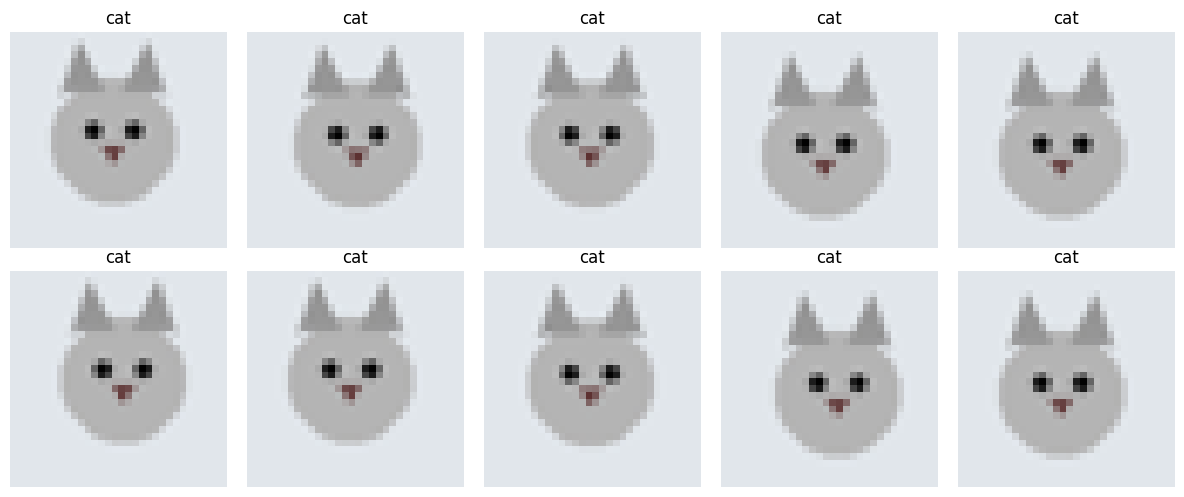

In [ ]:
fig,axes=plt.subplots(2,5,figsize=(12,5))
for ax,i in zip(axes.ravel(),range(10)):
    ax.imshow(X[i].reshape(32,32,3)); ax.set_title(y[i]); ax.axis("off")
plt.tight_layout(); plt.show()
# Vérification visuelle : images et labels doivent être cohérents.

# ÉTAPE 05 : Train / Test

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y
)
print("Train:",X_train.shape)
print("Test :",X_test.shape)
# Train = apprentissage ; Test = données jamais vues pendant l'apprentissage.

Train: (96, 3072)
Test : (24, 3072)


# ÉTAPE 06 : Construire la Pipeline
Le scaler et le classifieur sont sauvegardés ensemble.

In [ ]:
model=Pipeline([
    ("scaler",StandardScaler()),
    ("classifier",LogisticRegression(max_iter=2000,random_state=42))
])
print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])


# ÉTAPE 07 : Entraîner

In [ ]:
model.fit(X_train,y_train)
print("Entraînement terminé.")

Entraînement terminé.


/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:164: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:164: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:164: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:173: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:173: RuntimeWarning: overflow encountered in matmul
  norm2_w =

# ÉTAPE 08 : Évaluer

In [ ]:
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(classification_report(y_test,y_pred))
# Accuracy = proportion de prédictions correctes sur le jeu de test.

Accuracy : 1.0000 (100.00%)
              precision    recall  f1-score   support

         cat       1.00      1.00      1.00        12
         dog       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# ÉTAPE 09 : Matrice de confusion

[[12  0]
 [ 0 12]]


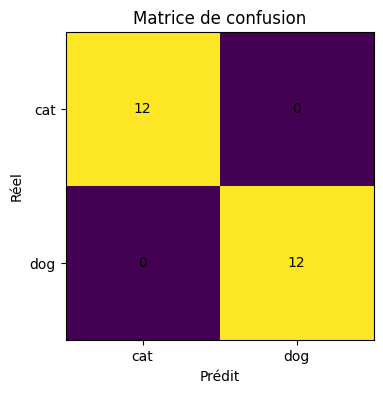

In [ ]:
cm=confusion_matrix(y_test,y_pred,labels=["cat","dog"])
print(cm)
fig,ax=plt.subplots(figsize=(5,4)); ax.imshow(cm)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["cat","dog"]); ax.set_yticklabels(["cat","dog"])
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel"); ax.set_title("Matrice de confusion")
for i in range(2):
    for j in range(2): ax.text(j,i,cm[i,j],ha="center",va="center")
plt.show()
# Diagonale = bonnes prédictions ; hors diagonale = erreurs.

# ÉTAPE 10 : Sauvegarder le modèle

In [ ]:
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH=MODEL_DIR/"image_classifier.pkl"
joblib.dump(model,MODEL_PATH)
print("Modèle sauvegardé :",MODEL_PATH)

Modèle sauvegardé : /Users/mac/Downloads/Data Science - Bootcamp/Deep Learning NVIDIA certified/08 Déployer un modèle d’IA avec FastAPI et Streamlit/fastapi_streamlit_image_project/model/image_classifier.pkl


# ÉTAPE 11 : Simuler l'inférence FastAPI

In [ ]:
loaded_model=joblib.load(MODEL_PATH)
pred=loaded_model.predict(X_test[:1])[0]
proba=loaded_model.predict_proba(X_test[:1])[0]
print("Réel :",y_test[0])
print("Prédit:",pred)
print("Probabilités:",dict(zip(loaded_model.classes_,proba)))
# FastAPI fera essentiellement la même opération après preprocessing.

Réel : dog
Prédit: dog
Probabilités: {np.str_('cat'): np.float64(3.796291947466557e-09), np.str_('dog'): np.float64(0.999999996203708)}


/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mac/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Le fichier `model/image_classifier.pkl` est maintenant prêt.

**FastAPI** : charge le modèle et expose `POST /predict`.

**Streamlit** : offre une interface graphique et appelle FastAPI.

Le dataset inclus est synthétique et petit : les performances sont pédagogiques et ne constituent pas une mesure industrielle.

# Réaliser par : OUARAS Khelil Rafik